<a href="https://colab.research.google.com/github/ldaniel-hm/eml_tabular/blob/main/MonteCarloTodasLasVisitas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Monte Carlo con Políticas epsilon-soft**

_Esto es un ejemplo de uso de Gymnasium e informe sobre un experimento de aprendizaje por refuerzo_

````
Luis D. Hernández.
<ldaniel at um.es>
````

Este notebook describe un experimento de aprendizaje por refuerzo utilizando el algoritmo de Monte Carlo con políticas epsilon-soft. El propósito de este análisis es entrenar un agente en un entorno de gym con el juego "FrozenLake", un entorno estándar en el que el agente debe aprender a moverse a través de un mapa en busca de una meta, evitando caer en agujeros. A continuación, se presenta una descripción de las diferentes partes del código y el proceso utilizado en el experimento.

🎯 **Ojo, el código debe modificarse para ser un auténtico Monte Carlo. Supongo que sabrás darte cuenta.**

## **1. Preparación del Entorno**

La preparación consta de las siguientes partes:
- **Instalación de Dependencias**: Se instalan las librerías necesarias para utilizar el entorno `gymnasium` para la simulación, con el objetivo de crear un ambiente controlado para que el agente pueda interactuar.
- **Importación de Librerías**: Se importan las bibliotecas necesarias como `numpy` para el manejo de matrices y `matplotlib` para la visualización de los resultados.

- **Importación del Entorno "FrozenLake"**:
Se cargan dos versiones del entorno "FrozenLake": una de 4x4 y otra de 8x8. Ambas versiones no son resbaladizas, lo que facilita la comprensión de los resultados, dado que el entorno resbaladizo podría dificultar la comprensión inicial del aprendizaje.

#### 3. **Funciones para Mostrar los Resultados**
   - Se define una función para graficar la proporción de recompensas obtenidas en cada episodio del entrenamiento. Esto ayuda a visualizar el progreso del agente en términos de su desempeño durante el entrenamiento.



##### _________ **Código de la Instalación e Importación**
----

In [57]:
%%capture
#@title Instalamos gym
!pip install 'gym[box2d]==0.20.0'

## Instalación de algunos paquetes.
#!apt-get update
## Para usar gymnasium[box2d]
#!apt install swig
#!pip install gymnasium[box2d]


In [58]:
#@title Importamos librerias
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
from abc import ABC, abstractmethod

# Garantizamos reproducibilidad
import random
random.seed(42)
np.random.seed(42)

In [59]:
#@title Importamos el lago helado
name = 'FrozenLake-v1'
env4 = gym.make(name, is_slippery=False, map_name="4x4", render_mode="ansi") # No resbaladizo para entender mejor los resultados.
env8 = gym.make(name, is_slippery=False, map_name="8x8", render_mode="ansi") # No resbaladizo para entender mejor los resultados.

## **2. Diseño del Agente**

El diseño del agente consta de dos partes, el algoritmo con el que aprende y las políticas (toma de decisiones) que realiza.

- **Políticas del Agente**
   - **Política epsilon-soft**: Se define una política donde todas las acciones tienen una probabilidad de ser elegida.
   - **Política epsilon-greedy**: basada en la política epsilon-soft. De esta forma el agente tiene una pequeña probabilidad de explorar (tomar una acción aleatoria) y una mayor probabilidad de explotar (tomar la acción que considera mejor). Esto permite equilibrar la exploración y la explotación.
   - **Política greedy**: Es la usada una vez que "ha aprendido".

- **Algoritmo de Iteración de Valor**
  - Se implementa el algoritmo de iteración de valor utilizando Monte Carlo.
  - Se usa una versión "on-policy" de Monte Carlo con políticas epsilon greedy sobre una política epsilon-soft.
  - Se basa en el criterio de todas las visitas.
  - Otro aspecto es que la actualización de los retornos no se realiza en el orden inverso a las visitas.

In [60]:
class Agent(ABC):
    def __init__(self, env: gym.Env, epsilon: float, epsilon_decay: float, final_epsilon: float, discount_factor: float):
        self.env = env
        self.discount_factor = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon
        self.training_error = []

    @abstractmethod
    def get_action(self, obs):
        pass

    @abstractmethod
    def update(self, episode):
        """En Monte Carlo, la actualización recibe el episodio completo."""
        pass

    @abstractmethod
    def get_current_policy(self):
        pass
    
    def decay_epsilon(self):
        self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)

In [61]:
class FrozenLakeAgentMC(Agent):
    def __init__(
        self, 
        env: gym.Env, 
        epsilon: float = 0.4, 
        epsilon_decay: float = 0.01, 
        final_epsilon: float = 0.01, 
        discount_factor: float = 1.0,
        use_inverse_decay: bool = False
    ):
        super().__init__(env, epsilon, epsilon_decay, final_epsilon, discount_factor)
        
        # Inicializamos la tabla Q y el contador de visitas (N)
        self.q_values = np.zeros([env.observation_space.n, env.action_space.n])
        self.n_visits = np.zeros([env.observation_space.n, env.action_space.n])
        self.use_inverse_decay = use_inverse_decay
        self.t = 0 # Contador interno de episodios para decaimiento
        self.env.action_space.seed(42) # Reproducibilidad en la acción aleatoria

    def get_action(self, state):
        """Política epsilon-greedy evaluada de forma dinámica."""
        if np.random.random() < self.epsilon:
            return self.env.action_space.sample(), True
        else:
            return int(np.argmax(self.q_values[state, :])), False

    def update(self, episode):
        """
        Auténtico Monte Carlo. 
        Calcula el retorno G recorriendo el episodio hacia atrás para asignar 
        el crédito temporal correcto a cada par estado-acción.
        """
        G = 0.0
        # episode contiene tuplas (estado, acción, recompensa_siguiente)
        for state, action, reward in reversed(episode):
            G = reward + self.discount_factor * G
            self.n_visits[state, action] += 1.0
            
            # Tasa de aprendizaje incremental alpha = 1 / N(s,a)
            alpha = 1.0 / self.n_visits[state, action]
            
            # Actualizamos el valor Q
            self.q_values[state, action] += alpha * (G - self.q_values[state, action])
            
        return G # Retornamos el G inicial (para estadísticas)

    def get_current_policy(self):
        """Extrae la política determinista a partir de los Q-values."""
        policy = np.zeros(self.env.observation_space.n, dtype=int)
        for state in range(self.env.observation_space.n):
            policy[state] = int(np.argmax(self.q_values[state]))
        return policy

    def decay_epsilon(self):
        """Aplica el decaimiento lineal o el decaimiento basado en t."""
        self.t += 1
        if self.use_inverse_decay:
            self.epsilon = min(1.0, 1000.0 / self.t)
        else:
            super().decay_epsilon()

In [62]:
def train_agent_mc(agent, n_episodes):
    list_stats = []
    episode_lengths = []
    stats = 0.0
    first_success_found = False # NUEVO
    
    for t in tqdm(range(n_episodes)):
        obs, info = agent.env.reset(seed=100 if t==0 else None)
        done = False
        episode = []
        
        while not done:
            action, is_exploring = agent.get_action(obs)
            next_obs, reward, terminated, truncated, info = agent.env.step(action)
            done = terminated or truncated
            episode.append((obs, action, reward))
            obs = next_obs
            
        # Detectamos si es el primer éxito ANTES de actualizar
        episode_reward = sum([x[2] for x in episode])
        if episode_reward > 0 and not first_success_found:
            print("\n==============================")
            print(f"Primer estado terminal alcanzado en episodio {t}")
            print("Política ANTES de actualizar:\n", agent.get_current_policy())
            print("==============================\n")
            
            agent.update(episode) # Actualizamos
            
            print("\n==============================")
            print("Política DESPUÉS de actualizar:\n", agent.get_current_policy())
            print("==============================\n")
            first_success_found = True
        else:
            agent.update(episode) # Actualización normal
        
        agent.decay_epsilon()
        
        stats += episode_reward
        list_stats.append(stats / (t + 1))
        episode_lengths.append(len(episode))
        
    return list_stats, episode_lengths

def plot_results(list_stats, episode_lengths, title_suffix=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Gráfica de Proporción de recompensas
    ax1.plot(range(len(list_stats)), list_stats, color='blue')
    ax1.set_title(f'Proporción de Recompensas {title_suffix}')
    ax1.set_xlabel('Episodio')
    ax1.set_ylabel('Proporción')
    ax1.set_xscale("log")
    ax1.grid(True)
    
    # Gráfica de Longitud del episodio
    episodes = np.arange(len(episode_lengths))
    ax2.plot(episodes, episode_lengths, alpha=0.3, label="Longitud", color='orange')
    
    # Media móvil
    window = max(10, len(episode_lengths) // 100)
    moving_avg = np.convolve(episode_lengths, np.ones(window)/window, mode='valid')
    ax2.plot(np.arange(len(moving_avg)), moving_avg, linewidth=2, label="Media móvil", color='red')
    
    ax2.set_xscale("log")
    ax2.set_xlabel('Episodio')
    ax2.set_ylabel('Longitud')
    ax2.set_title(f'Longitud de Episodios {title_suffix}')
    ax2.grid(True)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()


# @title Política final
def pi_star_from_Q(env, q_values):
    done = False
    pi_star = np.zeros([env.observation_space.n, env.action_space.n])
    state, info = env.reset()
    actions = ""
    while not done:
        action = np.argmax(q_values[state, :])
        actions += f"{action}, "
        pi_star[state, action] = action
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
    return pi_star, actions

#### **Código de las políticas y algoritmo MC**
----------------

## **3. Experimentación**

   - En esta sección, el algoritmo de Monte Carlo con la política epsilon (decaimiento) se ejecuta tanto para el entorno de 4x4 como al de 8x8 de FrozenLake sin resbalar.
   
   - En ambos casos se realiza un entrenamiento con un número determinado de episodios (5000 en concreto)

   - Además en el escenario 8x8 el  epsilon tiene decaimiento de acuerdo a la expresión: $\epsilon = min(1.0, 1000.0/(t+1))$

   - Durante el entrenamiento hay una visualización de la proporción de recompensas obtenidas a lo largo del entrenamiento.

   - Junto a dicho volcado se muestra gráficamente la proporcion de recompensas obtendias.

   - También se hace un volcado de los valores Q de cada estado, donde se muestra cómo el agente valora diferentes acciones en distintos estados del entorno, lo que puede interpretarse como su conocimiento sobre las mejores estrategias para alcanzar la meta sin caer en los agujeros.

   - Además, se muestra la política óptima derivada de los valores Q. Esta política es la que el agente seguiría si tuviera que elegir siempre la acción que maximiza su recompensa esperada.

   

### **3.1 Repressentaciones Gráficas**

Para comprobar el aprendizaje se mostrará la función $f(t)=\frac{\sum_{i=1}^t R_i}{t}$ para $t=1,2,\ldots, NumeroEpisodios$. La justificación es la siguiente. Como sabemmos que el retorno en el estados inicial 1 (pues no hay descuento) o 9, si se divide por el número de episodios ejecutados se calcular el porcentaje de recompensas positivas obtenidas. Dicho de otra forma, nos dirá el porcentaje de veces que el agente ha llegado al estado terminal.

*TODO:* Contruir una gráfica que muestre la longitud de los episodios en cada estado junto con la curva de tendencia.

### **3.2 Experimentación en el escenario 4x4**



   - Se realizan 5000 epsisodios y se actualizan los valores Q (valor de acción) basándose en las recompensas obtenidas durante cada episodio completo (e.d. aplicamos Monte Carlo) Se apica una política $\epsilon$ greedy sobre una política $\epsilon$ soft con un valor $\epsilon$ constante




=== ENTRENANDO ESCENARIO 4x4 ===


  6%|▋         | 3166/50000 [00:00<00:08, 5326.38it/s]


Primer estado terminal alcanzado en episodio 1861
Política ANTES de actualizar:
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


Política DESPUÉS de actualizar:
 [1 0 0 0 1 0 0 0 2 1 0 0 0 2 2 0]



100%|██████████| 50000/50000 [00:06<00:00, 8178.79it/s]


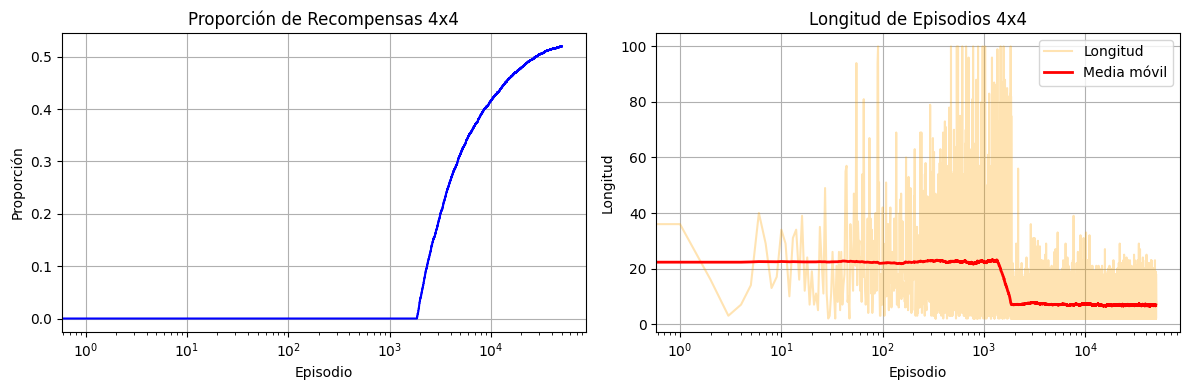

Máxima proporción 4x4: 0.5197



In [63]:
print("=== ENTRENANDO ESCENARIO 4x4 ===")
agent_4x4 = FrozenLakeAgentMC(
    env=env4, 
    epsilon=0.4, 
    epsilon_decay=0.0, # epsilon constante (decay_rate = 0)
    final_epsilon=0.4,
    use_inverse_decay=False
)

stats_4x4, lengths_4x4 = train_agent_mc(agent_4x4, n_episodes=50000)
plot_results(stats_4x4, lengths_4x4, "4x4")
print(f"Máxima proporción 4x4: {stats_4x4[-1]:.4f}\n")

In [64]:
# @title Estadísticas de los episodios
print(f"Longitud media de los episodios: {np.mean(lengths_4x4)}")
print(f"Longitud máxima de los episodios: {np.max(lengths_4x4)}")
print(f"Longitud mínima de los episodios: {np.min(lengths_4x4)}")
print(f"Longitud total de los episodios: {np.sum(lengths_4x4)}")
print(f"Número total de episodios: {len(lengths_4x4)}")

Longitud media de los episodios: 7.46638
Longitud máxima de los episodios: 100
Longitud mínima de los episodios: 2
Longitud total de los episodios: 373319
Número total de episodios: 50000


#### Mostramos los valores Q para cada estado. Cada estado tienen 4 valores, que se corresponden con las 4 acciones que se pueden en cada estado.

In [65]:
# @title Tabla de valores Q
LEFT, DOWN, RIGHT, UP = 0, 1, 2, 3
print("Valores Q para cada estado:\n", agent_4x4.q_values)


Valores Q para cada estado:
 [[0.15717227 0.52026509 0.36100696 0.3988121 ]
 [0.19086758 0.         0.5625     0.34149162]
 [0.36247723 0.62149254 0.49043716 0.5802005 ]
 [0.56269592 0.         0.55416667 0.4957265 ]
 [0.25902729 0.61263266 0.         0.46519033]
 [0.         0.         0.         0.        ]
 [0.         0.80202345 0.         0.60031596]
 [0.         0.         0.         0.        ]
 [0.38577508 0.         0.71720514 0.51143561]
 [0.58115183 0.82824671 0.79201577 0.        ]
 [0.68830128 0.95896147 0.         0.61723281]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.83546826 0.9605939  0.71681922]
 [0.82930144 0.95845539 1.         0.8071389 ]
 [0.         0.         0.         0.        ]]


- También se muestra la política óptima (greedy) obtenida a partir del aprendizaje anterior.

- Cada estado tienen 4 valores, pero todos son 0 menos 1. Es decir, en cada estado se aplica de manera determinística una única acción.

In [66]:
LEFT, DOWN, RIGHT, UP = 0, 1, 2, 3
pi, actions = pi_star_from_Q(agent_4x4.env, agent_4x4.q_values)

print("Política óptima obtenida\n", pi)
print(f"\n Acciones {actions} \n Para el siguiente grid\n", agent_4x4.env.render())


Política óptima obtenida
 [[0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 0. 0.]]

 Acciones 1, 1, 2, 1, 2, 2,  
 Para el siguiente grid
   (Right)
SFFF
FHFH
FFFH
HFFG



La gráfica de la longitud de los episodios es un buen indicador de aprendizaje por las siguientes razones:

- Fase de exploración inicial: Al principio, el agente actúa de manera aleatoria, por lo que suele caer rápidamente en los agujeros. Esto se traduce en episodios muy cortos. Nótese que la longitud máxima de los episodios es 100, por lo que si el agente no cae en un agujero, el episodio se trunca a los 100 pasos (por implementación de Gymnasium).
  
- Fase de aprendizaje: En el episodio 400 llega al estado terminal por primera vez. A partir de este instante, el valor de los estados empieza a cambiar y el agente comienza a aprender a evitar los agujeros y llegar de forma más rápida a la meta. Esto se refleja en una disminución de la longitud de episodios.

Por tanto, ver que la longitud sube y luego converge hacia el camino mínimo posible es un indicador claro de que el agente ha comprendido la dinámica del entorno.

### **3.3 Experimentación en el escenario 8x8**

  - Se realizan 5000 epsisodios y se actualizan los valores Q (valor de acción) basándose en las recompensas obtenidas durante cada episodio completo (e.d. aplicamos Monte Carlo) Se apica una política $\epsilon$ greedy sobre una política $\epsilon$ soft con un valor $\epsilon$ decreciente



=== ENTRENANDO ESCENARIO 8x8 ===


  2%|▏         | 1148/50000 [00:00<00:30, 1577.80it/s]


Primer estado terminal alcanzado en episodio 631
Política ANTES de actualizar:
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


Política DESPUÉS de actualizar:
 [0 2 2 2 2 0 1 3 0 0 0 0 0 2 3 3 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 2 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]



100%|██████████| 50000/50000 [00:16<00:00, 3090.37it/s]


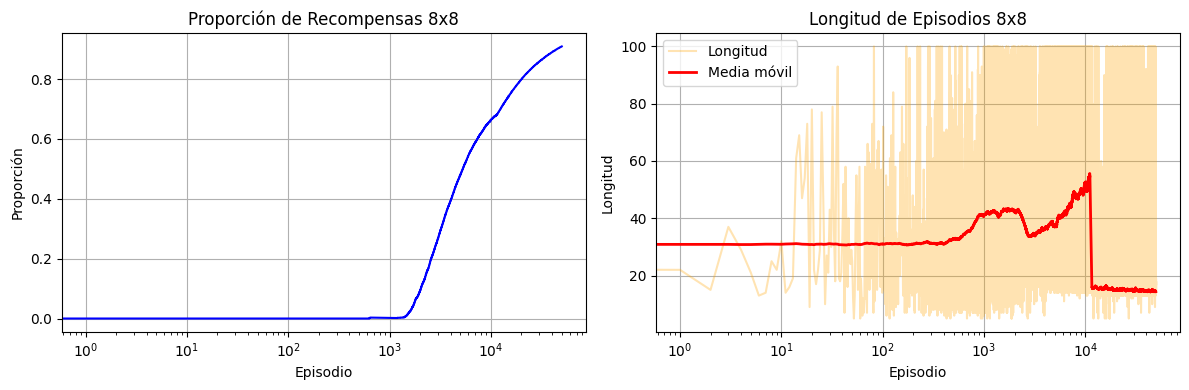

Máxima proporción 8x8: 0.9089

Valores Q finales (Muestra del estado 0 en 8x8): [0.66618434 0.57221906 0.90410959 0.57531536]
Política final 8x8 extraída:
 [2 2 2 2 2 2 1 0 3 3 3 3 1 2 2 1 3 3 1 0 3 2 1 1 0 0 0 0 0 0 2 1 3 3 0 0 2
 2 2 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]


In [67]:
print("=== ENTRENANDO ESCENARIO 8x8 ===")
agent_8x8 = FrozenLakeAgentMC(
    env=env8, 
    epsilon=0.4, 
    use_inverse_decay=True # Habilita la fórmula min(1.0, 1000/t)
)

stats_8x8, lengths_8x8 = train_agent_mc(agent_8x8, n_episodes=50000)
plot_results(stats_8x8, lengths_8x8, "8x8")
print(f"Máxima proporción 8x8: {stats_8x8[-1]:.4f}\n")

print("Valores Q finales (Muestra del estado 0 en 8x8):", agent_8x8.q_values[0])
print("Política final 8x8 extraída:\n", agent_8x8.get_current_policy())

#### Mostramos los valores Q para cada estado. Cada estado tienen 4 valores, que se corresponden con las 4 acciones que se pueden en cada estado.

In [68]:
# @title Tabla de valores Q
LEFT, DOWN, RIGHT, UP = 0, 1, 2, 3
print("Valores Q para cada estado:\n", agent_8x8.q_values)


Valores Q para cada estado:
 [[0.66618434 0.57221906 0.90410959 0.57531536]
 [0.34261242 0.41259357 0.91667821 0.38543517]
 [0.47802496 0.46187128 0.92467051 0.45708481]
 [0.53783615 0.53492763 0.93301849 0.55934343]
 [0.61285501 0.43525741 0.94276115 0.64270153]
 [0.62549485 0.64758065 0.94659243 0.58832012]
 [0.65824666 0.94147381 0.68188513 0.66867925]
 [0.70548204 0.39440204 0.34405941 0.3592233 ]
 [0.23167155 0.23128492 0.27984234 0.59998197]
 [0.08719053 0.07964602 0.12598425 0.5105973 ]
 [0.08957952 0.05137615 0.05970149 0.53243717]
 [0.13521127 0.         0.13207547 0.63864407]
 [0.35201794 0.49333159 0.3943662  0.41666667]
 [0.20588235 0.26797386 0.75302013 0.25649351]
 [0.66642229 0.67056245 0.9435492  0.67292419]
 [0.67053364 0.95655576 0.59171706 0.64985163]
 [0.04772727 0.0407911  0.04878049 0.31176875]
 [0.02542373 0.00384615 0.01796407 0.14758621]
 [0.01612903 0.08100559 0.         0.0242915 ]
 [0.         0.         0.         0.        ]
 [0.         0.22891566 0.47407

- También se muestra la política óptima (greedy) obtenida a partir del aprendizaje anterior.

- Cada estado tienen 4 valores, pero todos son 0 menos 1. Es decir, en cada estado se aplica de manera determinística una única acción.

In [69]:
# @title Política final
LEFT, DOWN, RIGHT, UP = 0,1,2,3
pi, actions = pi_star_from_Q(agent_8x8.env, agent_8x8.q_values)

print("Política óptima obtenida\n", pi)
print(f"\n Acciones {actions} \n Para el siguiente grid\n", agent_8x8.env.render())

Política óptima obtenida
 [[0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

 Acciones 2,

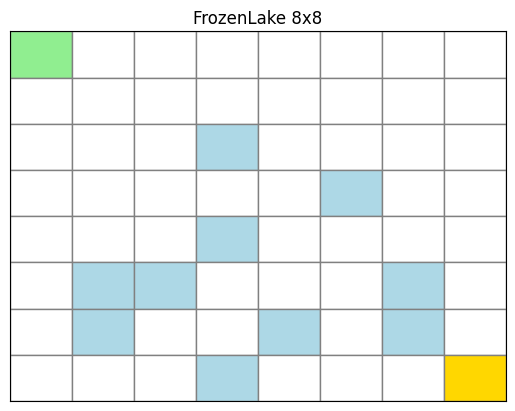

In [70]:
# @title Representación gráfica FrozenLake 8x8
import matplotlib.pyplot as plt

grid = [
    list("SFFFFFFF"),
    list("FFFFFFFF"),
    list("FFFHFFFF"),
    list("FFFFFHFF"),
    list("FFFHFFFF"),
    list("FHHFFFHF"),
    list("FHFFHFHF"),
    list("FFFHFFFG")
]

n = 8
fig, ax = plt.subplots()

for i in range(n):
    for j in range(n):
        cell = grid[i][j]
        
        color = {
            'S': 'lightgreen',
            'F': 'white',
            'H': 'lightblue',
            'G': 'gold'
        }[cell]
        
        rect = plt.Rectangle((j, n-i-1), 1, 1, facecolor=color, edgecolor='gray')
        ax.add_patch(rect)

ax.set_xlim(0, n)
ax.set_ylim(0, n)
ax.set_xticks([])
ax.set_yticks([])
plt.title("FrozenLake 8x8")
plt.show()

## **4. Análisis y Estudios Futuros**

### **4.1 Análisis de Resultados**

- En los dos entornos (4x4 y 8x8), el agente comienza con un conocimiento muy limitado, pero gradualmente mejora su desempeño a medida que avanza en los episodios. Este comportamiento se puede observar en el gráfico de la proporción de recompensas, que aumenta con el tiempo.
- En el entorno 4x4, la máxima proporción de éxito alcanzada fue 0.522, mientras que en el entorno 8x8, la máxima alcanzada fue 0.914. Esto refleja que el agente aprendió a optimizar su estrategia en un entorno más complejo.
- La política óptima obtenida muestra las acciones recomendadas por el agente en cada estado del entorno. En el entorno 8x8, la política es más compleja debido a la mayor cantidad de estados y la dificultad del entorno.

### **4.2 Propuestas para Estudios Futuros**

1. **Evaluar con Otros Entornos**: Sería interesante aplicar este algoritmo a otros entornos más complejos de `gym`, como "Taxi-v3" o "MountainCar", para analizar cómo se comporta el agente en situaciones con dinámicas más complicadas.
   
2. **Optimización del Decaimiento de Epsilon**: Aunque se utilizó un decaimiento de epsilon en el segundo experimento, se podría investigar la efectividad de diferentes tasas de decaimiento o incluso explorar algoritmos como `Q-learning` para comparar su desempeño. Graficamente se trataría de mostrar la curva de la tasa de aciertos para distintas funciones de decaimientos

3. **Análisis del Impacto de los descuentos en las Recompensas**: El estudio se ha hecho para $\gamma = 1$; pero no se ha probado qué pasa cuando  $0 \leq \gamma < 1$. Se trataría de estudiar la curva para distintos valores de $\gamma$

4. **Nuevas gráficas**: Aquí solo se ha usado la proporción de aciertos, pero sería interesante qué relación entre dicha tasa y las tamaños de los episodios.

4. **Ampliación del Algoritmo**: Explorar otros enfoques de Monte Carlo o incluso combinar Monte Carlo con otros algoritmos de aprendizaje por refuerzo, como el Deep Q-Network (DQN), podría mejorar aún más los resultados en entornos más complejos.
